# Notebook 02: Model Training

**HeartSense**: Heart Disease Risk Prediction for Early Clinical Decision Support

CSC8204: AI & ML | Group 6 | Uganda Christian University | Easter 2026

---


**Workflow Steps 4 and 5: Data Preprocessing, Feature Engineering, and Model Training**

**Purpose:** Build preprocessing pipelines, engineer features, train and tune all three models (LR, RF, XGBoost), and compare cross-validation results.

In [1]:
import sys, os, time, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_validate
)
from sklearn.pipeline import Pipeline

from src.config import (
    TARGET, ALL_FEATURES, RANDOM_STATE, TEST_SIZE, N_FOLDS,
    NUMERIC_FEATURES, NOMINAL_FEATURES, ORDINAL_FEATURES,
    PASSTHROUGH_FEATURES, STRESS_TEST_FEATURES
)
from src.data_loader import load_data_for_modeling
from src.feature_engineering import apply_feature_engineering
from src.preprocessing import build_preprocessor, get_feature_names
from src.modeling import build_model_pipeline, get_model_definitions
from src.artifacts import save_model, save_json, save_dataframe

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 1: Data Loading, Feature Engineering & Train-Test Split

In [2]:
# Load data with zeros replaced by NaN
df = load_data_for_modeling()
print(f"Dataset shape: {df.shape}")
print(f"NaN counts after zero replacement:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Apply feature engineering
df = apply_feature_engineering(df)
print(f"\nAfter feature engineering: {df.shape}")
print(f"New features: BP_Category, HighCholesterol")
print(df[["BP_Category", "HighCholesterol"]].describe())

# Define feature set (original 11 features + 2 engineered)
feature_cols = ALL_FEATURES + ["BP_Category", "HighCholesterol"]
X = df[feature_cols]
y = df[TARGET]

# Stratified train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} records")
print(f"Test set:  {X_test.shape[0]} records")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nTest class distribution:\n{y_test.value_counts()}")

# Compute positive class weight for XGBoost
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight = n_neg / n_pos
print(f"\nXGBoost scale_pos_weight: {pos_weight:.3f}")

Dataset shape: (918, 12)
NaN counts after zero replacement:
RestingBP        1
Cholesterol    172
dtype: int64

After feature engineering: (918, 14)
New features: BP_Category, HighCholesterol
       BP_Category  HighCholesterol
count   917.000000       746.000000
mean      1.417666         0.475871
std       0.769956         0.499753
min       0.000000         0.000000
25%       1.000000         0.000000
50%       2.000000         0.000000
75%       2.000000         1.000000
max       2.000000         1.000000

Train set: 734 records
Test set:  184 records

Train class distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64

Test class distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64

XGBoost scale_pos_weight: 0.808


## Section 2: Preprocessing Pipeline Construction

Two pipeline variants:
- **Scaled** (with StandardScaler) for Logistic Regression
- **Unscaled** for tree-based models (RF, XGBoost)

Design notes:
- `drop='first'` in OneHotEncoder reduces redundancy for LR. Shared across all models for pipeline consistency.
- ST_Slope is ordinal-encoded (Down < Flat < Up) per clinical convention.
- All transformations are fitted on training data only.

In [3]:
# Test the preprocessor: fit on training data, inspect output
preprocessor_scaled = build_preprocessor(scale_numeric=True, feature_set="full")
preprocessor_unscaled = build_preprocessor(scale_numeric=False, feature_set="full")

# Fit on training data only
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)

# Get feature names after encoding
feature_names_out = get_feature_names(preprocessor_scaled)
print(f"Output features ({len(feature_names_out)}):")
for i, name in enumerate(feature_names_out):
    print(f"  {i:2d}. {name}")

print(f"\nScaled output shape: {X_train_scaled.shape}")
print(f"Unscaled output shape: {X_train_unscaled.shape}")

Output features (14):
   0. numeric__Age
   1. numeric__RestingBP
   2. numeric__Cholesterol
   3. numeric__MaxHR
   4. numeric__Oldpeak
   5. nominal__Sex_M
   6. nominal__ChestPainType_ATA
   7. nominal__ChestPainType_NAP
   8. nominal__ChestPainType_TA
   9. nominal__RestingECG_Normal
  10. nominal__RestingECG_ST
  11. nominal__ExerciseAngina_Y
  12. ordinal__ST_Slope
  13. passthrough__FastingBS

Scaled output shape: (734, 14)
Unscaled output shape: (734, 14)


## Section 3: Baseline Model Training (No Tuning)

Train all three models with default hyperparameters + class_weight='balanced'.
5-fold stratified cross-validation on the training set to establish baselines.

In [4]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = ["recall", "precision", "f1", "roc_auc", "average_precision"]

baseline_results = {}
for model_key in ["lr", "rf", "xgb"]:
    pipeline, _, model_name = build_model_pipeline(model_key, pos_weight=pos_weight)
    
    print(f"\n{'='*50}")
    print(f"  Baseline: {model_name}")
    print(f"{'='*50}")
    
    t0 = time.time()
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv,
                                scoring=scoring, return_train_score=True)
    elapsed = time.time() - t0
    
    result = {}
    for metric in scoring:
        test_key = f"test_{metric}"
        mean_val = cv_results[test_key].mean()
        std_val = cv_results[test_key].std()
        result[metric] = {"mean": round(mean_val, 4), "std": round(std_val, 4)}
        print(f"  {metric:25s}: {mean_val:.4f} +/- {std_val:.4f}")
    
    result["time"] = round(elapsed, 1)
    baseline_results[model_key] = {"name": model_name, "metrics": result}
    print(f"  Time: {elapsed:.1f}s")

# Comparison table
print("\n\nBASELINE COMPARISON TABLE")
print("=" * 70)
header = f"{'Model':25s} {'Recall':>10s} {'Precision':>10s} {'F1':>10s} {'ROC-AUC':>10s}"
print(header)
print("-" * 70)
for key, res in baseline_results.items():
    m = res["metrics"]
    print(f"{res['name']:25s} {m['recall']['mean']:10.4f} {m['precision']['mean']:10.4f} "
          f"{m['f1']['mean']:10.4f} {m['roc_auc']['mean']:10.4f}")


  Baseline: Logistic Regression
  recall                   : 0.8424 +/- 0.0163
  precision                : 0.8684 +/- 0.0435
  f1                       : 0.8544 +/- 0.0208
  roc_auc                  : 0.9154 +/- 0.0352
  average_precision        : 0.9120 +/- 0.0433
  Time: 1.5s

  Baseline: Random Forest
  recall                   : 0.8991 +/- 0.0175
  precision                : 0.8557 +/- 0.0454
  f1                       : 0.8760 +/- 0.0222
  roc_auc                  : 0.9245 +/- 0.0295
  average_precision        : 0.9215 +/- 0.0283
  Time: 5.5s

  Baseline: XGBoost
  recall                   : 0.8818 +/- 0.0238
  precision                : 0.8709 +/- 0.0365
  f1                       : 0.8756 +/- 0.0173
  roc_auc                  : 0.9145 +/- 0.0202
  average_precision        : 0.9111 +/- 0.0215
  Time: 2.7s


BASELINE COMPARISON TABLE
Model                         Recall  Precision         F1    ROC-AUC
----------------------------------------------------------------------
Logist

## Section 4: Hyperparameter Tuning via GridSearchCV

Tuning with stratified 5-fold CV on training set. Scoring: recall (primary metric for screening).

**Note:** RF grid has 432 combinations, XGBoost has 486. Using RandomizedSearchCV with n_iter=80 for these to keep runtime manageable.

In [5]:
from sklearn.model_selection import RandomizedSearchCV

tuned_pipelines = {}
tuning_results = {}

for model_key in ["lr", "rf", "xgb"]:
    pipeline, param_grid, model_name = build_model_pipeline(
        model_key, pos_weight=pos_weight
    )
    
    print(f"\n{'='*60}")
    print(f"  Tuning: {model_name}")
    print(f"{'='*60}")
    
    # LR has a small grid (15 combos) -> use GridSearchCV
    # RF and XGBoost have large grids -> use RandomizedSearchCV
    t0 = time.time()
    if model_key == "lr":
        search = GridSearchCV(
            pipeline, param_grid, cv=cv, scoring="recall",
            n_jobs=-1, verbose=0, refit=True
        )
    else:
        search = RandomizedSearchCV(
            pipeline, param_grid, cv=cv, scoring="recall",
            n_iter=80, n_jobs=-1, verbose=0, refit=True,
            random_state=RANDOM_STATE
        )
    
    search.fit(X_train, y_train)
    elapsed = time.time() - t0
    
    print(f"  Best recall (CV): {search.best_score_:.4f}")
    print(f"  Best params:")
    for k, v in search.best_params_.items():
        print(f"    {k}: {v}")
    print(f"  Tuning time: {elapsed:.1f}s")
    
    tuned_pipelines[model_key] = search.best_estimator_
    tuning_results[model_key] = {
        "name": model_name,
        "best_score": round(search.best_score_, 4),
        "best_params": {k: str(v) for k, v in search.best_params_.items()},
        "time_seconds": round(elapsed, 1),
    }


  Tuning: Logistic Regression
  Best recall (CV): 0.8547
  Best params:
    model__C: 0.1
    model__l1_ratio: 0.5
    model__penalty: l1
  Tuning time: 14.4s

  Tuning: Random Forest
  Best recall (CV): 0.9040
  Best params:
    model__n_estimators: 300
    model__min_samples_split: 2
    model__min_samples_leaf: 2
    model__max_features: log2
    model__max_depth: 15
  Tuning time: 92.3s

  Tuning: XGBoost
  Best recall (CV): 0.8868
  Best params:
    model__subsample: 1.0
    model__reg_lambda: 1
    model__reg_alpha: 0
    model__n_estimators: 300
    model__max_depth: 7
    model__learning_rate: 0.2
  Tuning time: 21.3s


## Section 5: Cross-Validation Results Comparison (Tuned Models)

TUNED MODEL CV COMPARISON

Logistic Regression:
  recall                   : 0.8547 +/- 0.0214
  precision                : 0.8597 +/- 0.0426
  f1                       : 0.8561 +/- 0.0168
  roc_auc                  : 0.9060 +/- 0.0336
  average_precision        : 0.9007 +/- 0.0378

Random Forest:
  recall                   : 0.9040 +/- 0.0247
  precision                : 0.8627 +/- 0.0479
  f1                       : 0.8818 +/- 0.0256
  roc_auc                  : 0.9280 +/- 0.0235
  average_precision        : 0.9306 +/- 0.0220

XGBoost:
  recall                   : 0.8868 +/- 0.0354
  precision                : 0.8561 +/- 0.0244
  f1                       : 0.8705 +/- 0.0186
  roc_auc                  : 0.9119 +/- 0.0237
  average_precision        : 0.9115 +/- 0.0231


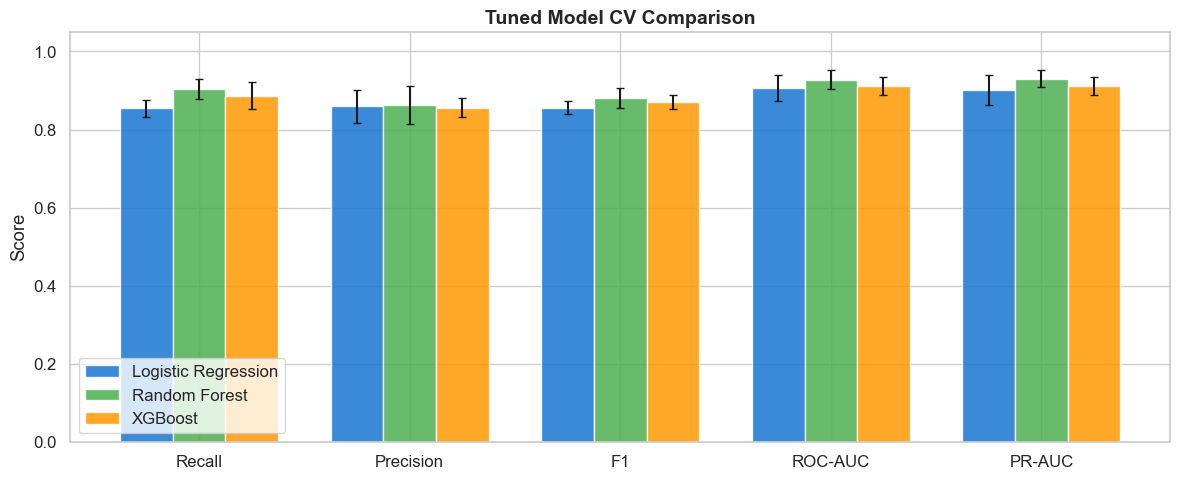

In [6]:
# Full CV evaluation of tuned models across all metrics
cv_comparison = []
cv_fold_scores = {}

for model_key in ["lr", "rf", "xgb"]:
    pipeline = tuned_pipelines[model_key]
    model_name = tuning_results[model_key]["name"]
    
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv,
                                scoring=scoring, return_train_score=False)
    
    row = {"model": model_name}
    fold_data = {}
    for metric in scoring:
        vals = cv_results[f"test_{metric}"]
        row[f"{metric}_mean"] = round(vals.mean(), 4)
        row[f"{metric}_std"] = round(vals.std(), 4)
        fold_data[metric] = vals.tolist()
    
    cv_comparison.append(row)
    cv_fold_scores[model_key] = fold_data

cv_df = pd.DataFrame(cv_comparison)
print("TUNED MODEL CV COMPARISON")
print("=" * 90)
for _, row in cv_df.iterrows():
    print(f"\n{row['model']}:")
    for metric in scoring:
        print(f"  {metric:25s}: {row[f'{metric}_mean']:.4f} +/- {row[f'{metric}_std']:.4f}")

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 5))
metrics_to_plot = ["recall", "precision", "f1", "roc_auc", "average_precision"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#1976D2", "#4CAF50", "#FF9800"]

for i, (_, row) in enumerate(cv_df.iterrows()):
    means = [row[f"{m}_mean"] for m in metrics_to_plot]
    stds = [row[f"{m}_std"] for m in metrics_to_plot]
    ax.bar(x + i * width, means, width, yerr=stds, label=row["model"],
           color=colors[i], alpha=0.85, capsize=3)

ax.set_xticks(x + width)
ax.set_xticklabels(["Recall", "Precision", "F1", "ROC-AUC", "PR-AUC"])
ax.set_ylabel("Score")
ax.set_title("Tuned Model CV Comparison", fontweight="bold", fontsize=14)
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("../outputs/figures/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 6: Save Training Artifacts

In [7]:
# Save all three tuned pipelines
for model_key in ["lr", "rf", "xgb"]:
    save_model(tuned_pipelines[model_key], f"{model_key}_pipeline.joblib")

# Save CV results table
save_dataframe(cv_df, "../outputs/tables", "cv_results.csv")

# Save tuning results (best params, best scores)
save_json(tuning_results, "../models", "tuning_results.json")

# Save CV fold scores for boxplot in Streamlit
save_json(cv_fold_scores, "../outputs/app_assets", "cv_fold_scores.json")

# Save train/test split for downstream notebooks
import joblib
joblib.dump({"X_train": X_train, "X_test": X_test,
             "y_train": y_train, "y_test": y_test,
             "feature_cols": feature_cols, "pos_weight": pos_weight},
            "../models/train_test_split.joblib")
print("Saved train/test split to models/train_test_split.joblib")

# Save feature column names
feature_names_out = get_feature_names(
    tuned_pipelines["lr"].named_steps["preprocessor"]
)
save_json({"full": feature_names_out, "input_features": feature_cols},
          "../models", "feature_columns.json")

print("\nAll training artifacts saved successfully.")

Saved model: F:\MY FILES\DATA SCIENCE\ML project\models\lr_pipeline.joblib
Saved model: F:\MY FILES\DATA SCIENCE\ML project\models\rf_pipeline.joblib
Saved model: F:\MY FILES\DATA SCIENCE\ML project\models\xgb_pipeline.joblib
Saved CSV: ..\outputs\tables\cv_results.csv
Saved JSON: ..\models\tuning_results.json
Saved JSON: ..\outputs\app_assets\cv_fold_scores.json
Saved train/test split to models/train_test_split.joblib
Saved JSON: ..\models\feature_columns.json

All training artifacts saved successfully.
